In [1]:
#| echo: false
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = "retina"
pd.set_option('display.max_columns', None)

color = ['#1f9aff', '#ff711f']

In [13]:
#| echo: false
data = pd.read_csv("data/enrollment.csv", sep=";")
data.columns = map(str.title, data.columns)

In [3]:
#| echo: false
uni = ['Theologische Universiteit Apeldoorn',
 'Radboud Universiteit Nijmegen',
 'Wageningen University',
 'Rijksuniversiteit Groningen',
 'Maastricht University',
 'Technische Universiteit Eindhoven',
 'Tilburg University',
 'Protestantse Theologische Universiteit',
 'Universiteit van Amsterdam',
 'Vrije Universiteit Amsterdam',
 'Universiteit Twente',
 'Theologische Universiteit Kampen',
 'Universiteit voor Humanistiek',
 'Universiteit Utrecht',
 'Technische Universiteit Delft',
 'Universiteit Leiden',
 'Erasmus Universiteit Rotterdam']

data = data[data['Instellingsnaam Actueel'].apply(lambda x: x in uni)]

In [4]:
#| echo: false
data_long = data.melt(id_vars=['Provincie', 'Gemeentenummer', 'Gemeentenaam', 'Soort Instelling', 
                               'Type Hoger Onderwijs', 'Brin Nummer Actueel', 'Instellingsnaam Actueel', 
                               'Croho Onderdeel', 'Croho Subonderdeel', 'Opleidingscode Actueel', 
                               'Opleidingsnaam Actueel', 'Opleidingsvorm', 'Geslacht'])
data_long["Opleidingsfase Actueel"] = data["Opleidingsnaam Actueel"].str[0:1].replace({"M": "Master", "B": "Bachelor"})
data_long['Jaar'] = pd.to_datetime(data_long['variable']).dt.year
data_long = data_long.drop('variable', axis=1)
data_long = data_long.rename(columns = {'value': 'Ingeschreven'})

data_long = data_long.melt(id_vars=['Provincie', 'Gemeentenummer', 'Gemeentenaam', 'Soort Instelling',
                               'Type Hoger Onderwijs', 'Brin Nummer Actueel','Instellingsnaam Actueel', 
                               'Croho Onderdeel', 'Croho Subonderdeel','Opleidingscode Actueel','Opleidingsvorm', 
                               'Opleidingsfase Actueel', 'Ingeschreven', 'Jaar', 'Geslacht'])


data_long.drop('variable', axis=1, inplace=True)
data_long['Croho Onderdeel'] = data_long['Croho Onderdeel'].str.title()
data_long['Gemeentenaam'] = data_long['Gemeentenaam'].str.title()
data_long.drop(['Brin Nummer Actueel', 'Opleidingscode Actueel'], axis=1, inplace=True)
data_long['Studie'] = data_long['value'].str.split(' ', 1, expand=True)[1]
data_long.drop('value', axis=1 ,inplace=True)
data_long['Studie'].fillna('Geneeskunde', inplace=True)
data_long["Ingeschreven"] = pd.to_numeric(data_long["Ingeschreven"].str.strip("<"))

In this post, I'll do a quick descriptive analysis of some enrolment data from Dutch universities. I won't do any predictive modelling or statistical testing. The data is provided by the [Dienst Uitvoering Onderwijs](https://duo.nl/open_onderwijsdata/hoger-onderwijs/aantal-studenten/studenten-wo.jsp), which is the executive organization for education of the Dutch government. The data ranges from 2017-2021.

This post is written in English. However, some of the labels in the figures are written in Dutch because the dataset contains categories written in this language. However, they aren't too hard to figure out!

This post is structured in the following way: First, we investigate the distribution of academic degrees. Secondly, we look at the differences in faculty enrolment between faculties and over time. After that, we analyze the geographical distribution of enrolled students. Last, I examine the differences between gender ratios regarding individual universities and study programs.

**Note:** Some "hogescholen" offer master degrees these schools are however.

## Academic Degrees

My first instinct is to analyze the count distribution between academic degrees. Netherlands has two general academic degrees. A bachelor degree and a master degree. The most bachelor degrees in take three years to obtain. An academic master's degree is a one-year or two-year course (and in exceptional cases more than two years long).

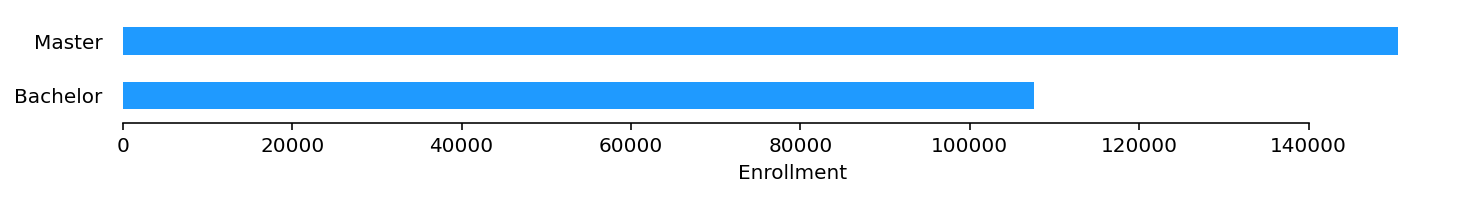

In [5]:
#| echo: false
#| label: fig-fase
#| fig-cap: "Proportion degree (2017-2021)"
#| layout-ncol: 1
#| column: pag
fig, ax = plt.subplots(figsize=(12, 1))

(data_long
 .groupby('Opleidingsfase Actueel')['Ingeschreven']
 .sum()
 .sort_values()
 .tail(3)
 .plot(kind='barh', ax=ax, color=color[0])
)

# plt.title('Academic degree in the period 2014-2018', fontsize=14)

plt.xlabel('Enrollment')
plt.ylabel('')

ax.tick_params(axis='y', length=0, pad=10)

sns.despine(left=True, trim=True)
plt.show()

As the figure above displays, most students enrol in a master's degree between 2014 and 2018.  However, if we take the bachelor's degrees together with the "propedeuse bachelor" degree, which is obtained after completion of the first-year bachelor, this category becomes most frequent.

## Faculty Enrolment

A faculty is a division within a university comprising one subject area or a group of related subject areas. Let's look at the differences of enrolment between faculties. The faculty "Gedrag en Maatschappij" (across all universities) has the most students enrolled between 2014 and 2018. Most Social and Behavioral Sciences are part of this faculty. As stated by [The Faculty of Social and Behavioral Sciences of the University of Amsterdam](https://www.uva.nl/en/about-the-uva/organisation/faculties/faculty-of-social-and-behavioural-sciences/organisation-and-contact/organisation.html):

>"Research and education at the Faculty address societal and human behaviour related themes, like the impact of new media on society, healthcare, urbanization, human and child development, mental health, inequalities, diversity and social cohesion."*

Some studies in this faculty are social sciences such as Anthropology, Economics (sometimes), Political Science, Psychology and Sociology and many more.


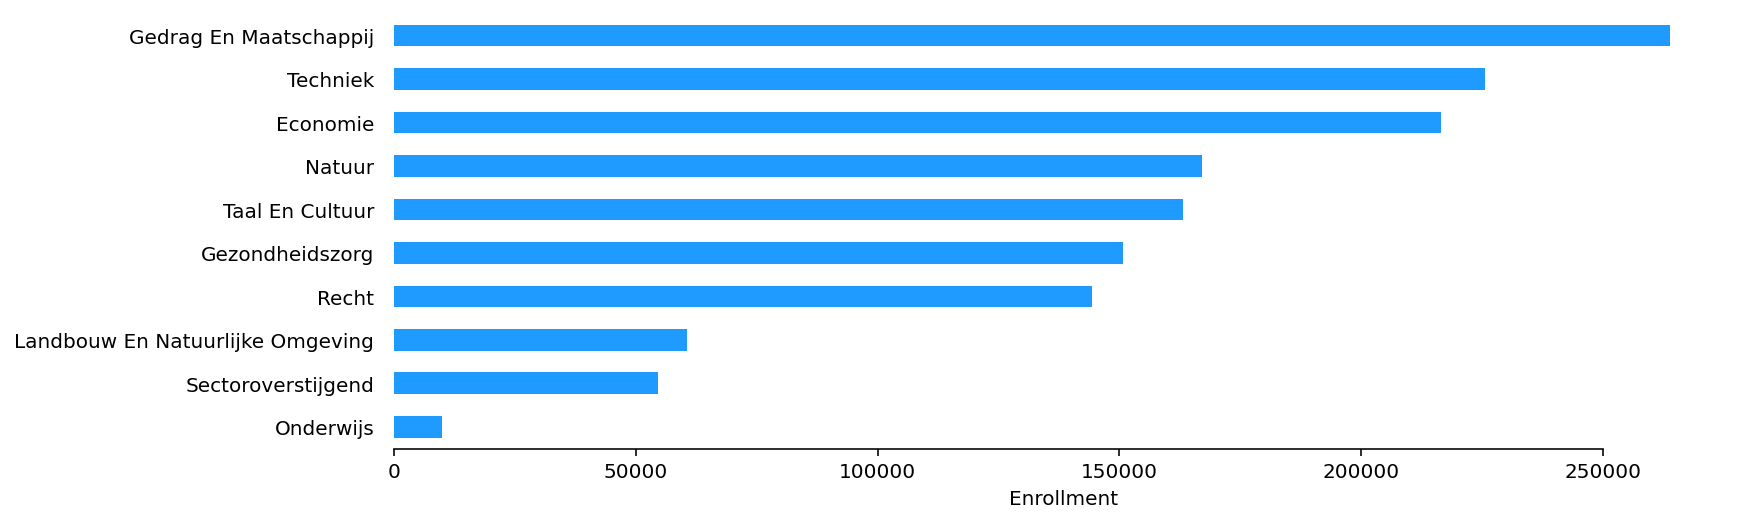

In [6]:
#| echo: false
#| label: fig-faculty
#| fig-cap: "Enrollment per faculty (2017-2021)"
#| layout-ncol: 1
#| column: pag
fig, ax = plt.subplots(figsize=(12, 4))

(data_long
 .groupby('Croho Onderdeel')['Ingeschreven']
 .sum()
 .sort_values()
 .plot(kind='barh', ax=ax, color=color[0])
)

# plt.title('Enrollment per faculty in the period 2014-2018', fontsize=14)

plt.xlabel('Enrollment')
plt.ylabel('')

ax.tick_params(axis='y', length=0, pad=10)

sns.despine(left=True, trim=True)
plt.show()

There is a large shortage of teachers in the Netherlands. This figure shows that in the 2014-2018 period, enrollment's at the education faculties were, in absolute terms, the lowest compared to other faculties. However, a connection between the two observations cannot be established. We can, however, try to find out whether there have been changes in the number of enrollment's over time. We do this by comparing the 2014 registrations with those of 2018.

We can see that almost all faculty enrollment's increased between 2014 and 2018. The biggest absolute increases are for the "Techniek" like Engineering and Computer Science programs and "Natuur" like Physics, Biology and Chemistry programs. Both consist of so-called "exact" or "hard" sciences. There is a lot of focus to increase technical studies in the Netherlands. Which seems to be working!

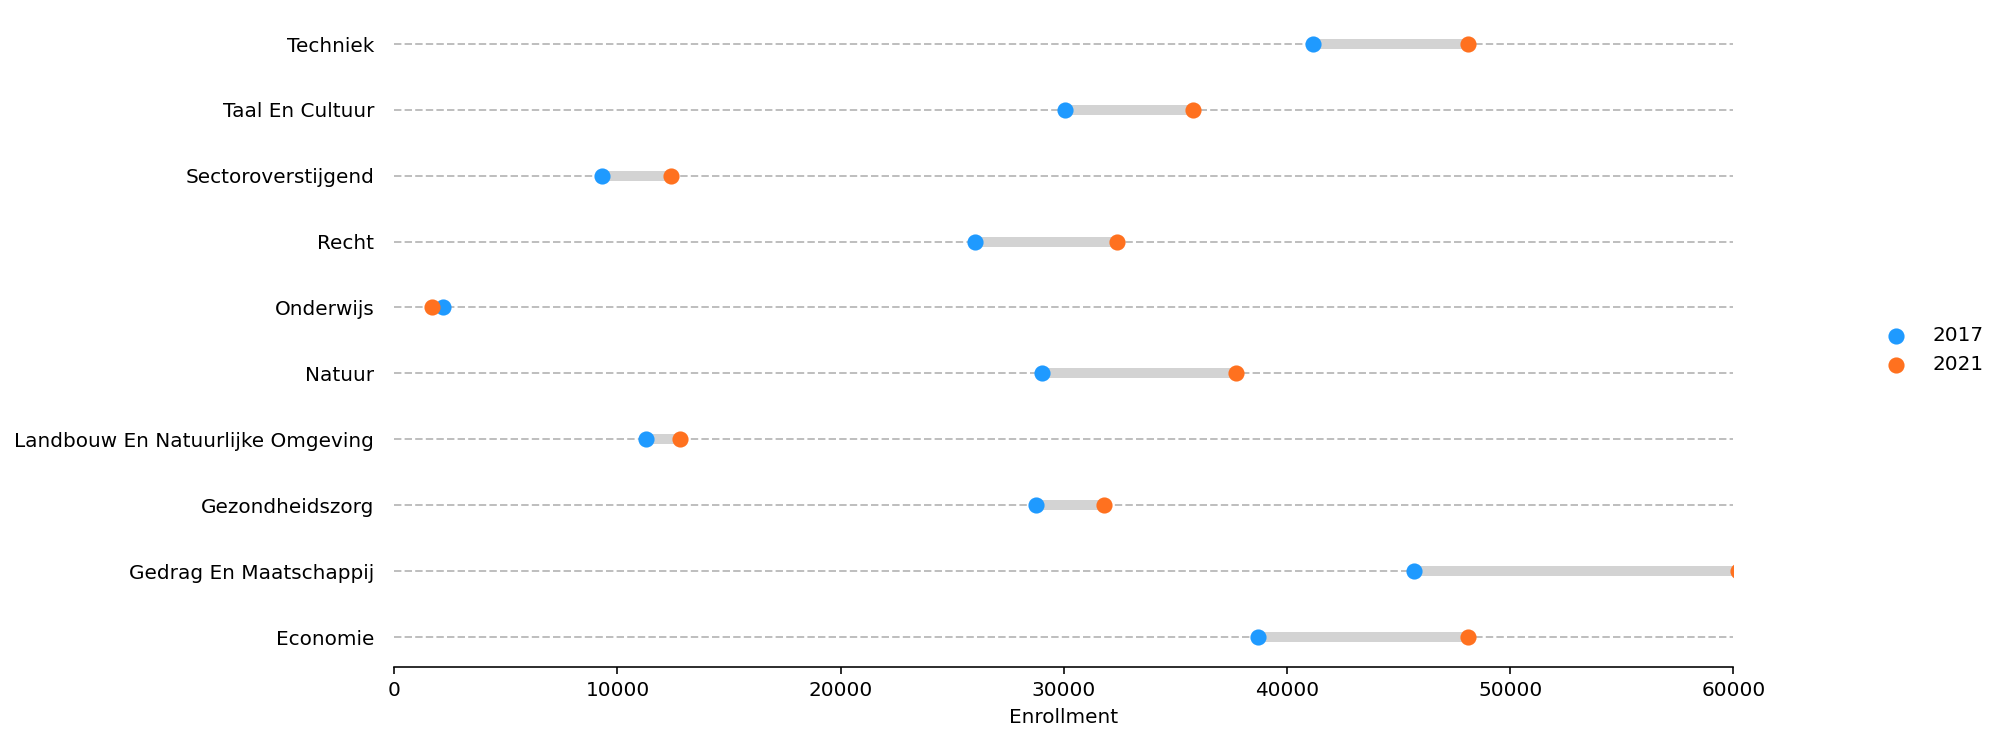

In [7]:
#| echo: false
#| label: fig-faculty-enrol
#| fig-cap: "Enrollment per faculty (2017-2021)"
#| layout-ncol: 1
#| column: pag

fac_2017 = (data_long
 .groupby(['Jaar', 'Croho Onderdeel'])['Ingeschreven']
 .sum()
 .unstack()
 .loc[2017]
)

fac_2021 = (data_long
 .groupby(['Jaar', 'Croho Onderdeel'])['Ingeschreven']
 .sum()
 .unstack()
 .loc[2021]
)

fac_pct_change = pd.DataFrame([fac_2017, fac_2021]).T.reset_index()
fac_pct_change.columns = ['Croho Onderdeel', '2017', '2021']

#Func to draw line segment
import matplotlib.lines as mlines
def newline(p1, p2, color='black'):
    ax = plt.gca()
    l = mlines.Line2D([p1[0],p2[0]], [p1[1],p2[1]], color="#d3d3d3", alpha=1 , zorder=-1, linewidth=5)
    ax.add_line(l)
    return l

fig, ax = plt.subplots(1,1,figsize=(12, 6))

ax.hlines(y=fac_pct_change['Croho Onderdeel'][:], xmin=0, xmax=60_000, color='gray', alpha=0.5, linewidth=1, linestyles='dashed', zorder=-2)
ax.scatter(y=fac_pct_change['Croho Onderdeel'], x=fac_pct_change['2017'], s=50, color=color[0], label='2017')
ax.scatter(y=fac_pct_change['Croho Onderdeel'], x=fac_pct_change['2021'], s=50, color=color[1], label='2021')

for i, p1, p2 in zip(fac_pct_change['Croho Onderdeel'], fac_pct_change['2017'], fac_pct_change['2021']):
    newline([p1, i], [p2, i])

ax.tick_params(axis='y', length=0, pad=10)

ax.legend(bbox_to_anchor=(1.2, 0.55), frameon=False)
plt.xlim(0, 60_000)

# plt.title('Enrollment per faculty over time (2017-2021)', fontsize=14)

plt.xlabel('Enrollment')
plt.ylabel('')

sns.despine(left=True)

plt.show()

The only faculty that has a decrease in enrollment's is the education faculty. This can be one of the explanations for the teacher shortage.

## Enrolment based on location and institution

Let's now look at the number of enrollment's based on the location. We have both city and province/state data. Not every province has a university. Therefore not all provinces will be represented in the graph below.

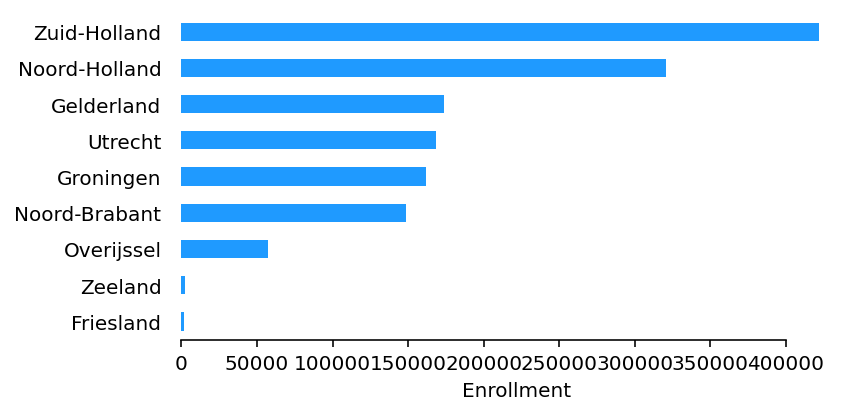

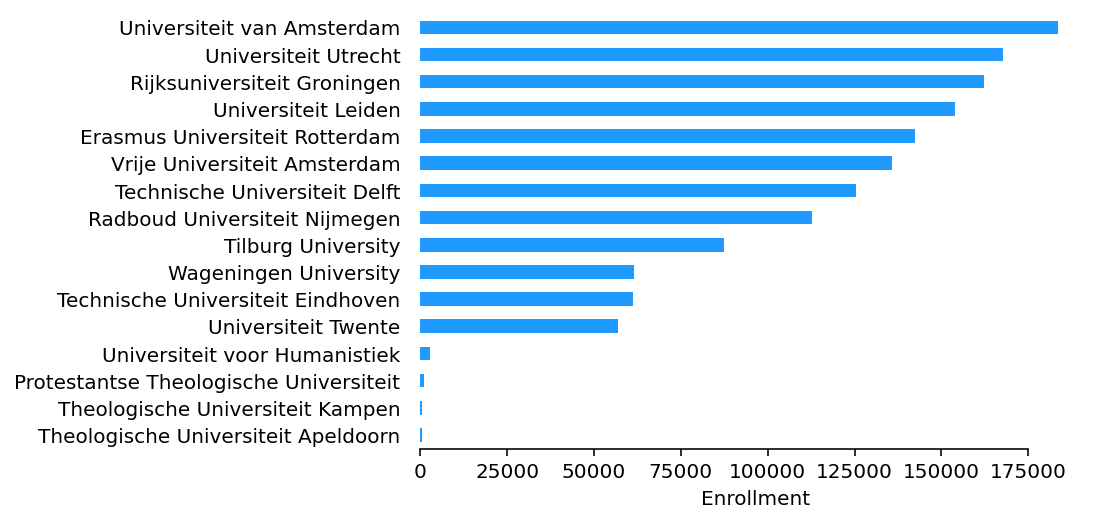

In [8]:
#| echo: false
#| label: fig-location
#| fig-cap: Province and university 
#| fig-subcap:
#|   - "Enrollment per province (2014-2018)"
#|   - "Enrollment per University (2014-2018)"
#| layout-ncol: 2
#| column: page

fig, ax = plt.subplots(figsize=(6, 3))

(data_long
 .groupby(['Provincie'])['Ingeschreven']
 .sum().sort_values()
 .plot(kind='barh', color=color[0]))

# plt.title('Enrollment per province in the period 2014-2018', fontsize=14)

plt.xlabel('Enrollment')
plt.ylabel('')

ax.tick_params(axis='y', length=0, pad=10)

sns.despine(left=True, trim=True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

(data_long
 .groupby(['Instellingsnaam Actueel'])['Ingeschreven']
 .sum().sort_values()
 .plot(kind='barh', color=color[0]))

# plt.title('Enrollment per University (2014-2018)', fontsize=14)

plt.xlabel('Enrollment')
plt.ylabel('')

ax.tick_params(axis='y', length=0, pad=10)

sns.despine(left=True, trim=True)
plt.show()



We see that both Zuid-Holland and Noord-Holland Universities have the most students enrolled. Both provinces also have the biggest populations what can be an explanation. Zuid-Holland as 3 universities and Noord-Holland has 2 universities.

Location can also be tied to the enrolment numbers for individual Universities.

We can see that the biggest enrolment universities are all located in the so-called "Randstad". This is a metropolitan area that includes the four largest cities in the Netherlands: Amsterdam, Rotterdam, The Hague, and Utrecht.

In [9]:
#| echo: false
# fig, ax = plt.subplots(figsize=(7, 6))

# (data_long
#  .groupby(['Instellingsnaam Actueel'])['Ingeschreven']
#  .sum().sort_values()
#  .plot(kind='barh', color=color[0]))

# plt.title('Enrollment per University (2014-2018)', fontsize=14)

# plt.xlabel('Enrollment')
# plt.ylabel('')

# ax.tick_params(axis='y', length=0, pad=10)

# sns.despine(left=True, trim=True)
# plt.show()

## Gender and Enrolment

Another variable included in the dataset is gender. We'll look at ratios between the enrolment of men and women at universities and fields of study.

The figure below displays the absolute ration of enrollment's based on gender at universities in the Netherlands between 2017 and 2021.

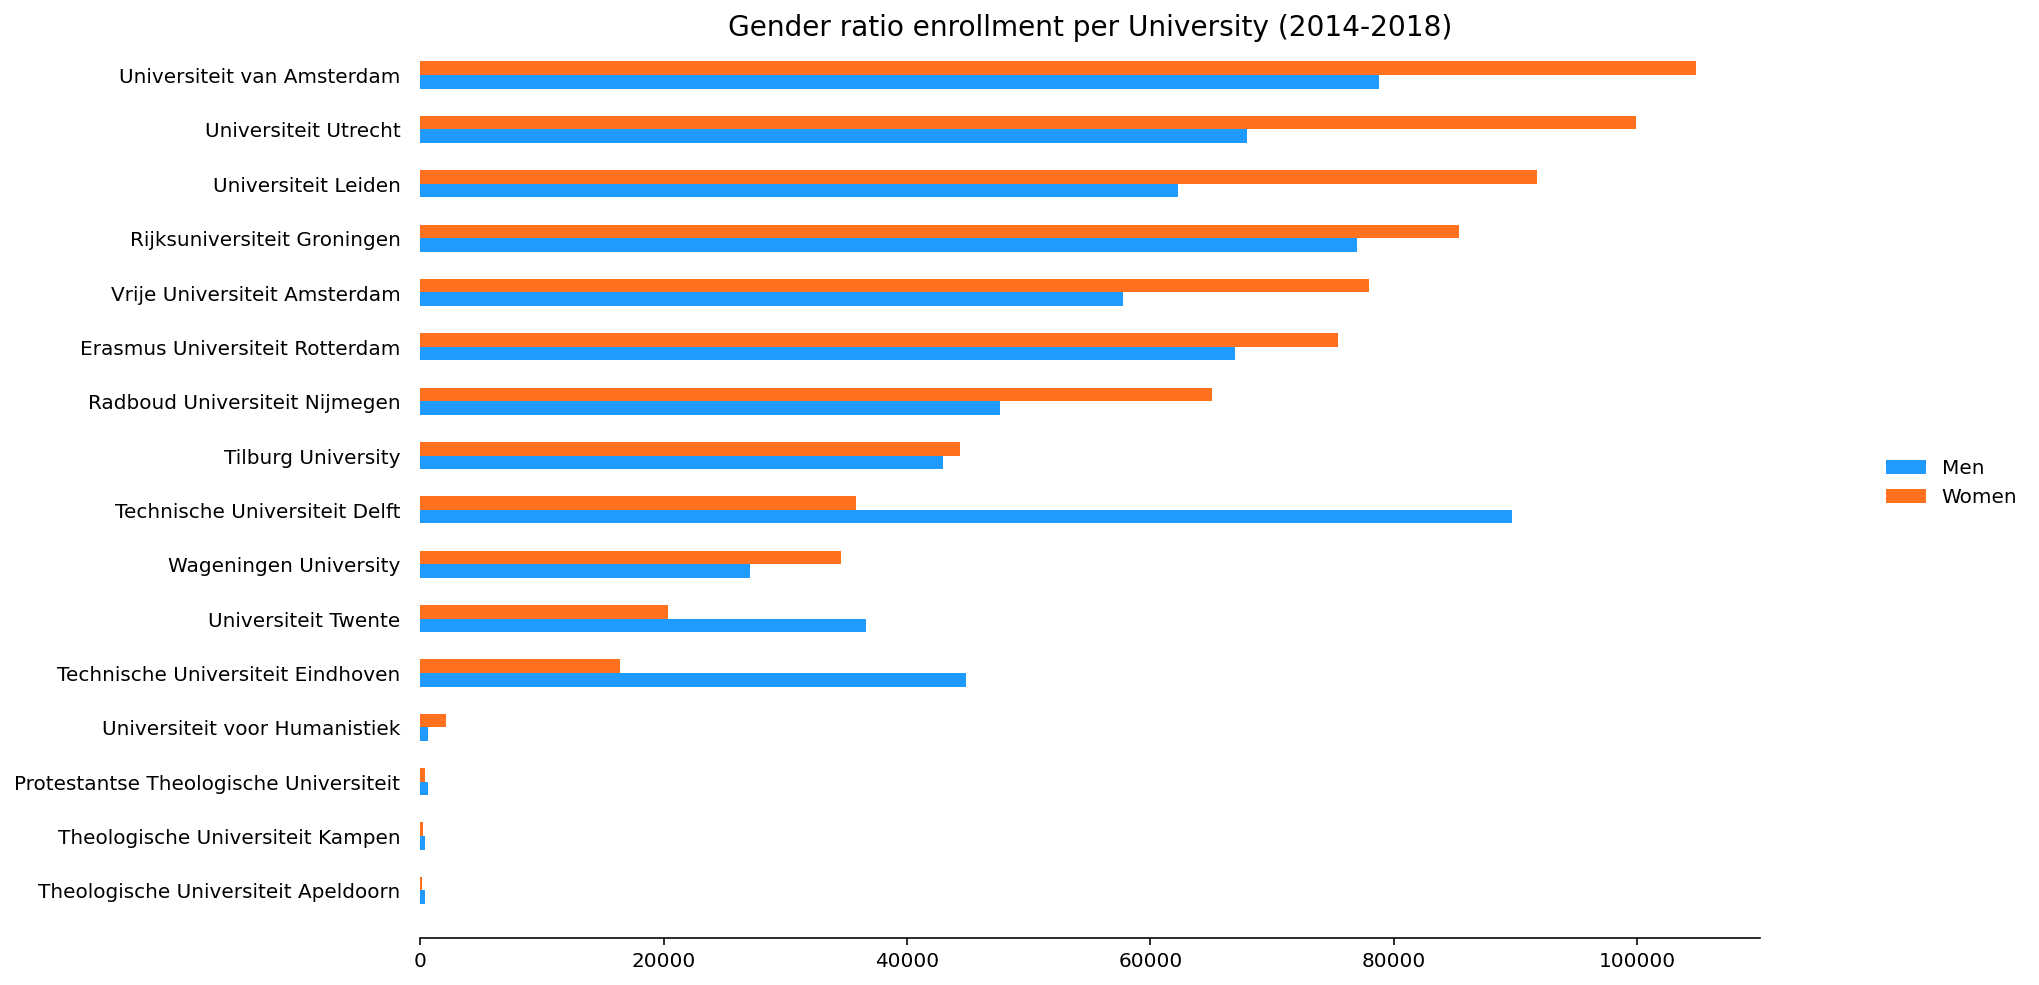

In [10]:
#| echo: false
#| label: fig-gender
#| fig-cap: "Gender ratio enrollment per University (2014-2018)"

fig, ax = plt.subplots(figsize=(12, 8))

(data_long
 .groupby(['Instellingsnaam Actueel','Geslacht'])['Ingeschreven']
 .sum()
 .unstack()
 .sort_values('vrouw')
 .plot(kind='barh', color=color, ax=ax))
plt.title('Gender ratio enrollment per University (2014-2018)', fontsize=14)
plt.ylabel('')
ax.tick_params(axis='y', length=0, pad=10)
plt.legend(loc="center right", borderaxespad=0.1, frameon=False, labels=['Men', 'Women'], bbox_to_anchor=(1.2, 0.50))
sns.despine(left=True, offset=10)

plt.show();

We can see that at almost all universities women are in the majority. The only universities where men have a clear majority are technical universities.

Let's look at the fields of study that have the biggest ratio of differences between men and women and vice versa. I excluded programs that have less than 100 enrollment's over 4 years to keep some robustness.

Most of the technical programs have a high ratio of men relative to women.  Automatic Technology has a ration of 42 to 1. Meaning that for every 42 men following the program 1 woman enrolled. On the other hand the non-research program Education and Child Studies as about a women ratio of 22 to 1.


In [11]:
#| echo: false

geslacht_studie = data_long.groupby(['Studie','Geslacht'])['Ingeschreven'].sum().unstack()
geslacht_studie = geslacht_studie[geslacht_studie.sum(axis=1) > 100]
geslacht_studie['Mannen per Vrouw'] = geslacht_studie['man'] / geslacht_studie['vrouw']
geslacht_studie['Vrouwen per Man'] = geslacht_studie['vrouw'] / geslacht_studie['man']
geslacht_studie['Vrouwen per Man'] = geslacht_studie['Vrouwen per Man']*-1
geslacht_studie = geslacht_studie.sort_values('Mannen per Vrouw')
geslacht_studie
geslacht_studie = geslacht_studie.iloc[np.r_[0:10, -10:0]][['Mannen per Vrouw', 'Vrouwen per Man']].reset_index()
geslacht_studie['Studie'] = geslacht_studie['Studie'].replace({'Developmental Psychopathology in Education and Child Studies (research)': 'DPiEaCS (research) *', 
                                   'Development and Socialisation in Childhood and Adolescence (research)': 'DaSiCaA (research) *'})


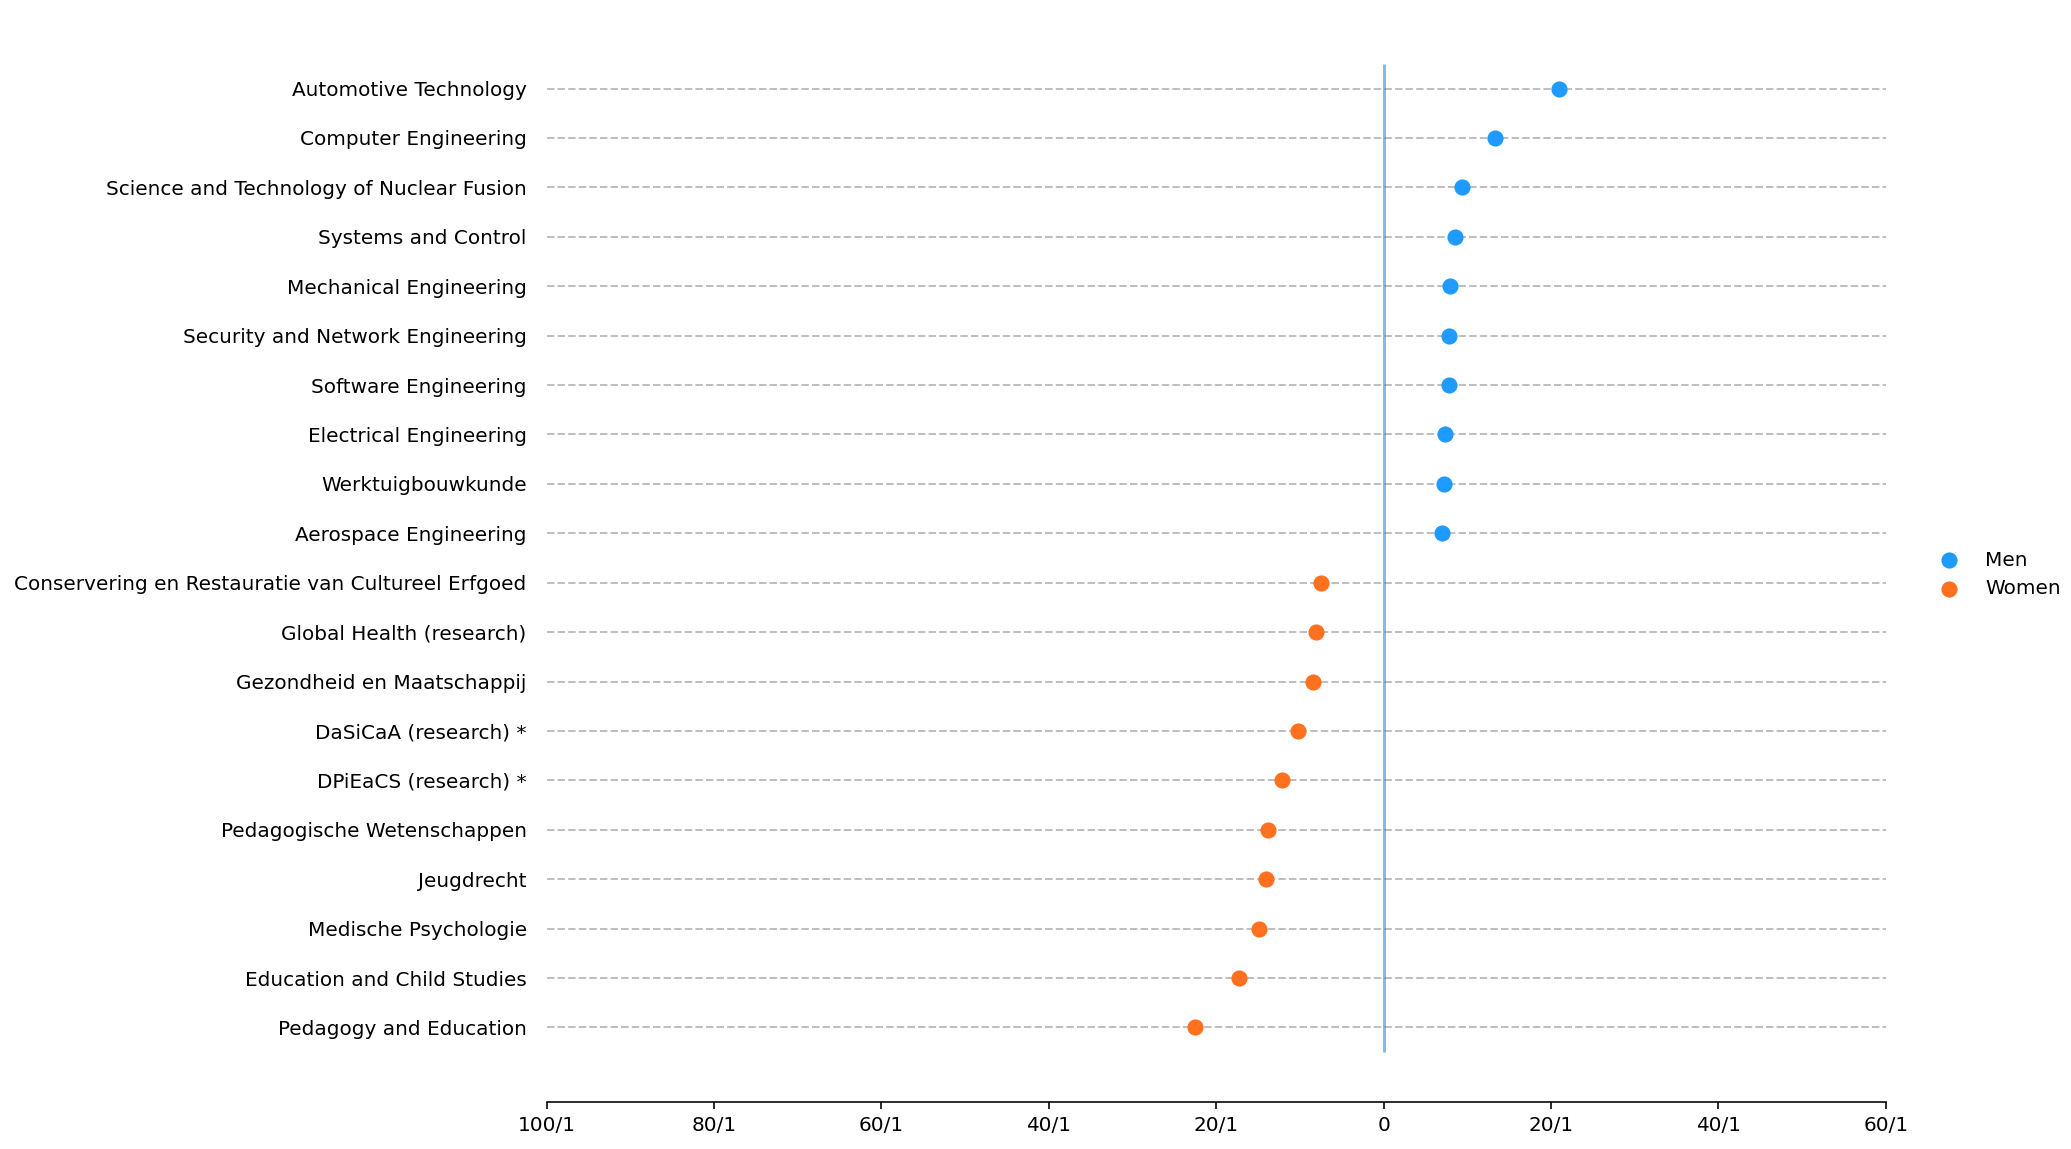

In [12]:
#| echo: false
#| label: fig-gender-study
#| fig-cap: "Top 20 biggest difference in gender ratio per field of study enrollment (2014-2018)"

fig, ax = plt.subplots(figsize=(12, 10))

ax.hlines(y=geslacht_studie['Studie'][:], xmin=-100, xmax=60, color='gray', alpha=0.5, linewidth=1, linestyles='dashed', zorder=-1)
ax.vlines(x=0, ymin=-0.5, ymax=19.5, alpha=0.5)

ax.scatter(y=geslacht_studie['Studie'][-10:], x = geslacht_studie['Mannen per Vrouw'][-10:], color=color[0], label='Men', s=50)
ax.scatter(y=geslacht_studie['Studie'][:10], x = geslacht_studie['Vrouwen per Man'][:10], color=color[1], label='Women', s=50)

# plt.title("Top 20 biggest difference in gender ratio per field of study enrollment (2014-2018)", fontsize=14)
plt.ylabel('')
plt.xlabel('')

plt.xticks(ticks=[-100,-80,-60, -40, -20, 0, 20, 40, 60], labels=['100/1','80/1','60/1','40/1','20/1','0','20/1', '40/1', '60/1'])
plt.xlim(-100, 60)
ax.tick_params(axis='y', length=0, pad=10)


fig.legend(loc="center right", borderaxespad=0.1, frameon=False)
sns.despine(left=True, offset=0)

plt.show()


These programs seem divided along with the "traditional"  view of gender divided fields of study. Men have the enrolment overhand in technical and computer science programs and women tend to have the overhand in programs focuses on education and health.

## Conclusion

In this post, I did a quick and basic analysis of University enrolment data. There are a lot more ways to analyze this data.  However, we saw that social studies programs have the highest enrolment in the period between 2014 and 2018.  That technical studies are growing fastest. Most enrolled students study at Universities in the "Randstad" and that there seem to be some traditional gender divisions for some programs.  

This code available on [
maxscheijen/dutch-university-enrollment-analysis
](https://github.com/maxscheijen/blog-post-code/tree/master/dutch-university-enrollment-analysis).